# Year 2 exit exam: defend a reproducible comparison

**PROVIDED / TODO / CHECK / EXIT.** Your deliverable is a fresh comparison plus a written defense. This capstone reuses three visible model implementations; it introduces no new paper. Read the protocol before running. Author-reference evidence is separate from your output.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## Cold retrieval

Explain the three tree biases, TabM training/inference, TabPFN context and TabICL stages before looking below. Predict which family will change most across regimes, and why.

## Concept recap

Log loss is −log of the probability of the observed label, averaged over rows. With y=1 and p=.8 it is .223 nats. Validation chooses recipes; test evaluates a frozen choice. Mean seed losses are ranked within each dataset. Seeds do not create independent datasets. Train-only imputation/scaling and a query context containing training labels only preserve the comparison boundary.

<figure class="exam-figure">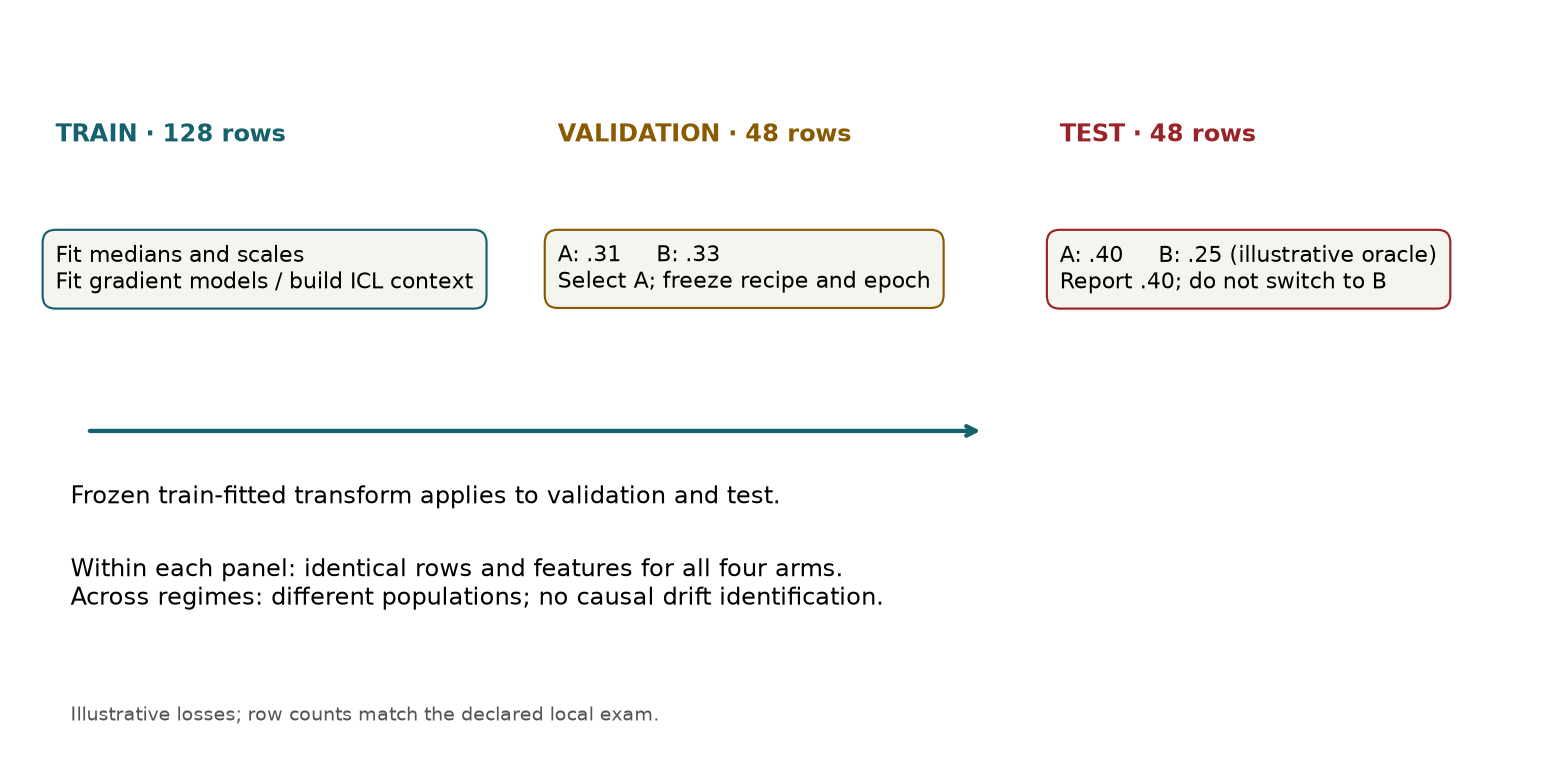<figcaption>Illustrative validation selection: .31 beats .33, so the selected test loss is .40 even if another candidate has .25.</figcaption></figure>

## Exact protocol and reproduction

# L080 reproducibility contract

This is the curriculum's cross-paper Year 2 exit experiment, **not a published experiment from any one paper**. The full declared local experiment is executable and its raw inputs are packaged. The architecture sources are visible in the notebook. Larger local runs are explicitly separate from original paper benchmark reproduction.

## Exact replay

From a course checkout, use Python 3.12 and `requirements-labs.txt`; the exact author package snapshot is `requirements-l080-observed.txt`. The observed snapshot is evidence of the environment, not a cross-platform dependency lock. Raw subsets under `labs/data/l080` include all numeric/binary features and exact row IDs/targets from the hash-pinned TabReD release.

```bash
.venv/bin/python labs/_check_l080.py
.venv/bin/python labs/_verify_l080.py --preset smoke --output /tmp/l080-smoke-new.json
.venv/bin/python labs/_verify_l080.py --preset exam --output /tmp/l080-exam-new.json
.venv/bin/python labs/_build_l080.py
.venv/bin/python labs/_execute_l080.py
```

Every result path must be new. There is no resume. A failure leaves `IN_PROGRESS`; never summarize it as complete. The operator checks the packaged raw-data SHA256 and the complete v2 checkpoint SHA256. If absent, the historical checkpoint is downloaded from its pinned Hugging Face revision. No API inference or paid service is used.

To reconstruct the subsets from original release archives rather than use packaged inputs:

```bash
.venv/bin/python labs/_prepare_l080.py --preset exam
```

`_fetch_l055.py` verifies official archive hashes. The packaged extraction records exact sampled IDs and full split time ranges. Data files are compressed without lossy rounding. Numeric data retain float32 as in the release; labels are int64. Sampling seeds 550/551/552 are fixed, label-blind and distinct from model seeds.

## Frozen local protocol

- Two real classification tasks: Ecom Offers and Homesite Insurance. Released random-0 and sliding-window-0 partitions. These are different train/test populations, not a controlled causal drift intervention.
- `exam`: 128 train, 48 validation, 48 test rows per panel; seeds 0/1/2; four arms; exactly two candidates each; 48 selected test records. `smoke`: 64/24/24, one seed, two epochs and 20 trees, 16 records. `extended`: 512/192/192, three seeds, 128 epochs and 800 trees; not run during authoring.
- All available numeric/binary columns (119 and 276), no feature selection. Categorical columns are omitted and counted. Train-only median imputation (all-missing columns → zero); neural gradient-trained arms additionally use train-only standardization. TabPFN receives imputed raw numeric values and its documented context-fitted numeric encoding.
- Binary log loss of P(y=1); float64-epsilon clipping. Candidates and gradient checkpoints use validation only; exact ties choose first. Test labels never reach fit or selection. No train+validation refit, repeated test selection or class-label context contamination.
- XGBoost: 120 rounds, depth 3/6, learning rate .05, subsample/column sample .8, CPU hist. This is **two-candidate tuning**, not a 4-hour GBDT search.
- FT-Transformer: full pinned released feature tokenizer, three PreNorm blocks with first attention norm omitted, ReGLU, CLS readout; width32, 4 heads, FFN factor4/3, attention/FFN dropout .1, residual dropout0; no compression. TabM: corrected numeric full BatchEnsemble variant, k8, width64, depth3, dropout .1; common shuffled batches. Both use AdamW, lr .001/.003, decay1e-4, batch32, 16 epochs with first best-validation checkpoint.
- Historical TabPFN v2: all 12 layers and every checkpoint tensor, frozen; temperature .7/1 selected on validation. No new pretraining. Simple numeric wrapper, no default feature/class ensemble, no categorical preprocessing/fingerprints. One whole validation query call, one whole test query call; query batch is part of the protocol. Model seed controls random feature identifiers, not pretraining uncertainty.
- Same rows, targets, metric and two declared candidates are matched. Candidate count does **not** equalize FLOPs, validation adaptivity, historical pretraining cost or serving latency. Per-arm seconds include candidate fitting/validation and selected prediction, exclude shared imputation, checkpoint download/load and common data loading. They are diagnostic host times, not a hardware-normalized efficiency ranking.
- Mean and sample SD across the three downstream seeds within each dataset/regime; ranks within dataset after seed averaging. Two datasets cannot support a broad winner or a reliable population significance claim. No Friedman/Nemenyi significance is asserted.
- Temporal row order does not prove every released aggregate and label was available at prediction time. Full split boundaries and strict-versus-tied status are recorded. Features are inherited from a release, not reconstructed from raw event histories.

## Source and paper protocol audit

| Component | Reproduced here | Difference from original results |
|---|---|---|
| FT-Transformer | Pinned released full architecture; copied-weight output and gradient check | Small fixed recipe, numeric-only task subset; no paper tuning/benchmark |
| TabM | Corrected full numeric BatchEnsemble, shared weights/adapters and mean member loss | k8 vs paper k32, common batches, small fixed grid, no numerical embeddings/quantile recipe/full tuning |
| TabPFN v2 | Full historical weights, all layers, simple declared numeric inference | No new pretraining, restricted wrapper, two temperatures, different evaluation data/protocol |
| Tuned GBDT | Fresh two-depth XGBoost selection | Neither paper-optimal tuning nor 4-hour Nature comparator |
| TabReD | Hash-pinned release data and split0, exact sampled row identities | Two tasks, caps, categorical omission, log loss; not Figure2's roster, task metrics, all splits and 15 seeds |
| TabICL | Written mechanism assessment with primary source | No TabICL inference arm is requested by this exam; NOT_RUN |

Original FT, TabM, TabPFN and TabReD paper-result reproduction: **NOT_RUN / INCOMPARABLE**. A matching score would not change that status. No fabricated paper target exists for this four-way cross-paper protocol. Follow the prior lesson contracts (L054, L055, L064, L066) for their individual published targets and unresolved gaps. Their old `paper` preset labels are not certificates of fidelity.

## Larger local extension (not original paper reproduction)

```bash
.venv/bin/python labs/_prepare_l080.py --preset extended
.venv/bin/python labs/_verify_l080.py --preset extended --output /tmp/l080-extended-new.json
```

The notebook exposes the same complete live operator behind `RUN_FRESH_COMPARISON`. Default solution execution audits all frozen exam predictions and performs the full four-arm/two-regime smoke with the student's functions. To reproduce the full author experiment choose `exam`. Use a new path. The notebook records its actual executed cell source alongside the result; repository hashes alone do not identify edited kernel code.

Live Colab, cloud execution, deployment and original paper pretraining remain NOT_CHECKED/NOT_RUN. The student must submit a fresh run plus written reasoning; author evidence is not the student's exit ticket.


## PROVIDED · author-reference evidence

**Fresh author training / frozen-v2 inference; not student output or paper-result reproduction.**

| Task / regime | XGBoost | FT-Transformer | TabM | TabPFN v2 |
|---|---:|---:|---:|---:|
| ecom-offers / random | 0.513 ± 0.023 | 0.410 ± 0.006 | 0.517 ± 0.023 | 0.436 ± 0.000 |
| ecom-offers / temporal | 0.764 ± 0.005 | 0.679 ± 0.017 | 0.758 ± 0.055 | 0.666 ± 0.001 |
| homesite-insurance / random | 0.339 ± 0.005 | 0.558 ± 0.022 | 0.512 ± 0.018 | 0.303 ± 0.000 |
| homesite-insurance / temporal | 0.338 ± 0.006 | 0.364 ± 0.012 | 0.350 ± 0.018 | 0.412 ± 0.000 |

Mean ± sample SD of test log loss across three seeds. Lower is better.
<figure class="exam-figure">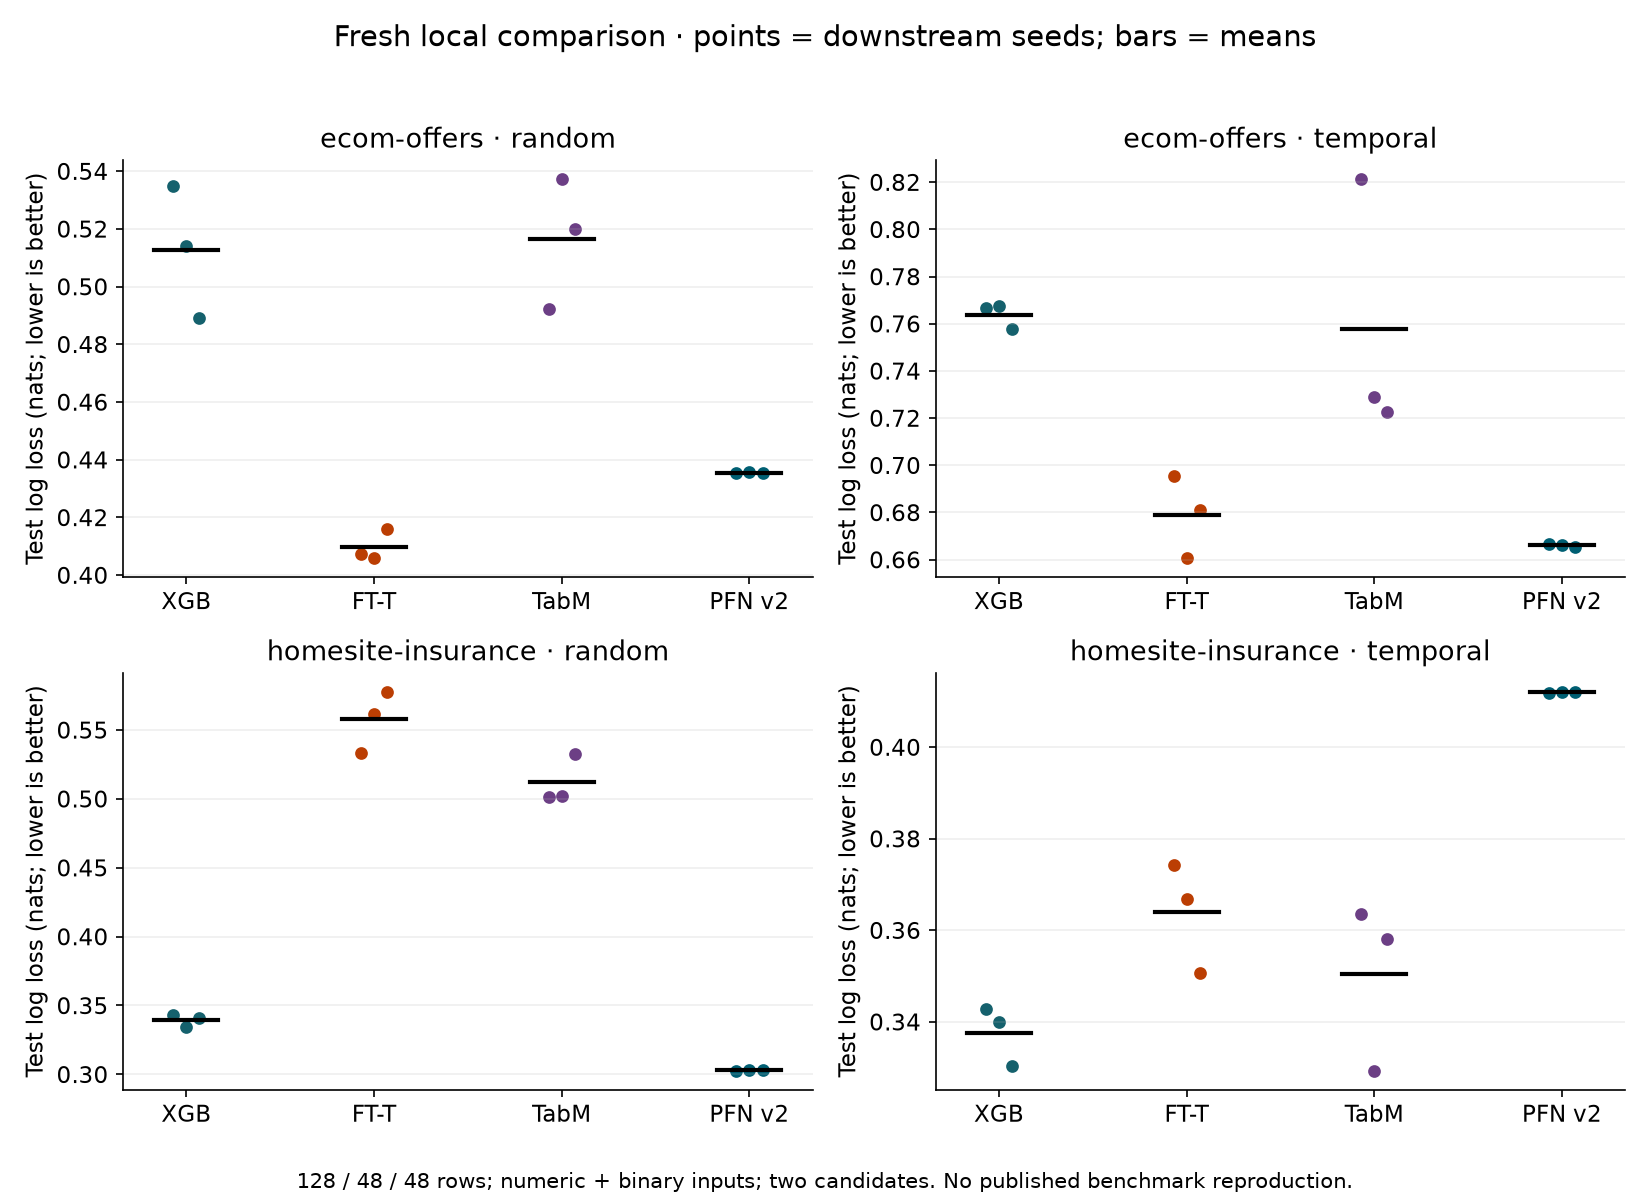<figcaption>Author-reference evidence: fresh local runs, three downstream seeds per task/regime. Dots show seeds; black bars show means.</figcaption></figure>

## PROVIDED · exact input archive

The following cell restores hashed raw subsets and author predictions. It does not manufacture a fresh result. If a local file differs, stop and inspect it.

In [ ]:
import base64,gzip,hashlib,json
from pathlib import Path
PACKAGED={'data/l080/exam.npz': {'sha256': 'fc14df7a8956afc98d3a7c56b28acd151329f84a82dcd009b1a4798088a80b17', 'gzip_base64': '...'}, 'data/l080/exam.json': {'sha256': '5826197e2d0b2cbc8ca6f8ce0de6e708c3407d52c6fc5effde6e26403d5b7326', 'gzip_base64': 'H4sIAAAAAAACA+2dzW4eya2G974KQesEIeuXzNmeKwiyCwKjJX3yCLAlQ5KDcxLk3sPSTGzzaU8i/0mWPVoMpunqquoqksXiS/L7x7Ojo+PX14ebw+3xH4+OD/+3vTr+3R1tuzy8vAnaP+Ipng+nV69+f3V+fri++cP1dnl29ertv8W/XpzdvPcYhNvr7eIySH95Szo60u71d+89l1nn+89V3NPzaOm5SbH0XGdLz+apv16sp+dp4/3nIaOk51rS/Kx5au+9SHoeJY2vUnIDlSFpxqpdNBFKsdxH7ZY+QlvNX62tt0zoMUwmxB8Ilr5URx95HlN6+nb10kYmeFMQPHVaVCUNu74tvVKqjLSjpWnJr7QxM48MrXmUMdDHmKogjJ75SvIoVU0y58USjkwYPfPinC3No7oUcKfnibWYe+bXpjozw9a8hM2lg2CZYbp4zUwdLOSZ62v+2l573speIQi91cyFwT9Ss+h4y51accvC1GuWrpiYZvGqILTScx8xbprHiF5BsCxiY/aZhXhay6+YeJr6FC9pprOIg1DZoud9mWXilaokjCxis7GP3vLHzeDs3CK+LvVhAlG3ELncIph9ZkLJw1pteecs9GKah03JDBOEgRamaU3NZk0tXK1aJoTAgJAnFrviuY/Zsuy7jTyP0EB5xZaSqplgmXFDa1lWn6EdsgQtSoUilw79KBJrnylKHSo6eCCoK8+MmTdMpRYoeGnNMcOdzpduUPpxumWVpbLT8hKcndW8hLhgdI9PBaVnkVqaH18aXWseXdWt8jQsE5Qx0PNwUibshqDYQM82C0b30LVvCX9992/Hf9te0lARwVknFadh6CXMqs9MKJxBLdjo3vD1YZDkpQ9ZzatqbWZGCH5Pr8QYWR+W2jI3hd7Oyi00Buyw2CrBeZl1ahwgM7ewkj+/xeGftiR0XZbd1kfLp+Hs+RBuoWVg4I0umcCTTEbmur7Mg3zGhGBkVe7iWVFbtlOnQ9QtzhTqwyyg5j3bQh5bm/WhzCzBS3NRNQyvVAQDbYbDXgyRdrQJQ5YUTC92vGcrSjWOawrnrHjLx/QPCtXt4eYWUlWFClMyV2ls54Ddmg/VsBfzopUQw7SstdZ8ANSmuFW0mb+99gLzsLcs/qE5BMZfy9/ShHeRMCkydysMtxD+PGzIaZb2NkeW1Obawd3g3TDrKwgdAjEMBqTPfJaPUKdZZOI8giVXICFF+sy2jTlsG80HTRg7ArtktHz9WlZXNhBwW/BueWKx5lmVxbflO6AbrLA4kotBtzceXWH+KDg/eAYHXnSDNtWygafaYJ3pYnEcVNN9vJOpX/7vn/9uc3y7Xb843N7nuv1+t/KrD3q/B/lhHvSpTEcfaFB9jK710dfg8XdOvy3e0UfnUf163PsVF+ShdkEeY3Vyb/e8YH3L+ulRBPVpHk1fcUs+uze977XkB7VyHkrn69P/7M8/df6DOX/+5uXL5zcXfz/8ikVvkq5WvyjTIvG35+s78n6Iw3b75vpugLixvyVfvbq4vT2cPT/dbg8vrq4vTreXz99rKu9uHBevDs+vt8sXh3uBfEBftJvafR1v93/5Q5L8X97eLczV9dnhOlbg5z14/fJi9Xi+vbw5vG1ycxsLc/v8bglOrt5cnm3XF3fLcNfs2Xv9JYT09vDq9dX13fd9HEZagcsVooETiBrgEMkegwEf24AHZ3oGKIPbCrCB7F8fHS56Orh9AvEsE/fkBtRUh6GFZSRJx4QfzCpeMcdN2xxebK+SPUcCh1fRmdG5uOFnz1GpzbH6o8DZ6hn1KF0y5lWWhyYTZodLy9DpaNnXXGLRWyb07NMsc1S08IwiFyPyanAlxXpl6LEuP3smeObWYEYHoeVvqdEkO46rZyihtpKx6tpsguD5a+sA1FanGNHbAQf2zG6XOh1TD0ZGtEER+OtmHqU1AIsttiW/Mnr28LcJpDH6zCvWYqPyK1byTJu1LITBpYOgcWbtIGSJ6trQglvZS8nREb3MvFG9avbn9locwHMnYcBdWUfe7E6Pb29ATXsD9NRjZvCBInAklFrGwbrNDPiF5Oe9HTKzP3coo0cUntZRLPsel9s0d7pYOSPiMkHQrKBDF6DTOBFyp/H5QDzAH6NPDDuK4tgoGXkNQubkQQgkCI0tssyNkMHcItS6A6rPLuAR5zfA/J43asQJ1EBoJMAVLT23mKUCiC8N2H0cBZIJiEOYC87KHvCeNf9cCwJ0P59zc868t/GMUeJ8riAMtsAooS5w5Jd+33u6LQgq2wfgJWP4iYWJUhGRUODor1l/x3GPUVrN/Git5cW0htCi4IvMoNYRr2RjEl/YRTWMXgnr5WAKK5kxzBCjZkEREDIyZA7wZNkuaGGIahCYdUFAVINoVhwuwMFcGc2mM2Paiy88E6xmeKVKlj6PQfIoceKDEFydYU7JoG4QGoDQAdxn4V4Z96kILgnhg10qDUAQLIA43tFHbByCSyRbme7QikG4P/ypYU61uoszAdAUBgPhKS26A6wYZ1J3bxHODQZxmOoFwVVBaYz9iINSGa9CGLc4TPzQ4gC1ZEW27SJYMHovjHKJI8MZwcILxxTcOGS2SbhbGfMTWgnzMWsYy3fz8VYrKXhrLZnsKIhOkUHQT2CA6PobhBwZY1Mq40tLEyeFkTBx5aiELhlRU6DGVCuw5wVmcobNEMKgfRcBu4dSQ3YxuqnirdCIDD2wUb44TKqPjl38oEjVk3Gn6zcMQ3zXPPq9OdO/N/+5Pjq/6QOByF8SD/jiMKk+lQgR/YbDUh4quOHxZUbue315KBF6MnE/+iTNMf2i+/OFteePDZNO/wiYFPf0blLvD5NadiJ+Ekx6e/3mk1DSn65eHW4ubg+/v7i8eROrdXr41HRSOH5twi+eL8Le4FPrHUgrg34Lkh60tpyfoE3hnuhwMukkXiu7lMiRUZS4wHcQEHy+ctEGEh4BMs4BKHN6dv7Et2UeKA7UoErLfrpaW3Zf1VEHUDbNS1itZU9eDJodqvGxiHkXRIG3juyjNpAn0Sby15o32eVIZnRrwcEZd7LsRYppZTfOKJKTE0apeV9Gx4qNAYRsJS/mPqxlVGkK9mUWJMTOMivyCiW7A+ccSPDTkmXBqk7A/EByLb4OPmk67b3D8+0OX3AwMlIAAct6GTlva6UAZimtNWMk3rBAIdfOrGzkrYjuEvwGY/41BJEUhhCsAIFMiZeQF1ZahasxxBVaooS+LaTApRsUh37qzrdGQ/JecbCx1gI4PYQHGWJaOxIvQ7EBo9BWgPdpG1KRmB6rKqAwJ6IFuyLHpxQ4VXurcFX3yVTGIUJKB/CnwVxIiQw9mWVWZ+1ZI+lK3MVbzTMwonN3AE+DNlBTyHZQdlEqRTF6HA+lMuUPWVc2HRwenIHRfSVTIaEfqTArxb8jmzCYBZSK5Cj12HgUAuhM5PLOuCXvE7ldbsI2sRz4ipU1nM9PxZyLxLmUY12kIe22SK/IipTugvCfUBMNlJ75OaaHvOdFyfJeQuQy4hXrHgt9X9POBgIiOrK14GGfKKkQq9gqzQVhpE8+c4viEB5gnh4c3xn8kQ9Q69mJH9pKiTtnSCpWJbOE2TCgqwhT8dkIPhnAU1Uu4Yono04OxT2hyRW6K2YHnVyjm9xztYpE4TDWoG+XuOS3GldCw8YBSNMVVQsWoAcNHJoTPYdhCM2wgmHQs7F+yJAGpgplBkjGlvqAhjGcoV4dOtnjYMFbCyGGtDLMTiYsiZCplvVSWWVRGL4XK3TfO9AyEbOphvgOJOfqoCIKvZPnGJeqPCH3HIa0jK6cZz2wx60hnLPLzFpqKtDzWZACOUdlEAmi0kwKAzIKrlLM1Q5zEEUk1rjZUBs70NU7wUnvBAynsiRAQT+6ckkJ/QE2j2MBsGeZHedWTBjwaShq6IXqChi2rdoomROWbZwp3nIcU1Bmh1XhAkmIK1mh/CBub0kLyuGIYHtDflDMJu4YqM0SEoUM9ji3Rt6LkLGOQNT4eIMcztDQXwJ0fXzv23eAWP4GDX3bntsnE0ygT0XMfssUf0Jz029Mkz9Ubur3VmZAfhio7cHOqU8CXeU7C7D4rg2bJ5Ogrp8Buq4ymu+Htn4m6lreuYP+G+r67gb2kbDr8nW7NfnlD74bjXvu+Pe/3ddj97ldfgii/aQ+v3J+6weQ209Oc6UbFWmotTLXDHXw6th50BAl3+ljmwaAJ5gXt22kkMR1F/do9ewWKw1Q+qpHNpDeiT5GNZarrchNhPurKYLwFxiTswaLo9Rs7XnYNgCkrSTKnIu3gvSz61mYz1fHfwZJV7WxhpLLE5l2cKR1q6hf68hLGcHxQF61IdMOOcWjSvbBj9rVmCWXO50zu+umNEUSmA4UgW2oerbQtpwEJqgtOFDScE4EFcSCZZfyNNRatGLIjqozYyIWOyVw6DGv2wAJu3W42glbimonpe3yTuZgoUxkhd4lPzAbQ1j60JCMreLKyqlemXuhKEOnK+mJdTqVlTuHGkuwjZ0T0gFfqbNGbNlp6iIVLvKiSPAMiha2ISBaGGqwEj8APJSqgGwL06aWz08JGKNYtNYyGPbSG2uUz13V8kmItJoD0miFBSBbRb5nUFjgsrUdOL0KhcJJO5Cp0waKTy/gGXvamBKmzVgnvXmHszcYqrLNhPu3izlAbvGpOwqBcEh+qH3myvQ6Cfk0FGsOykToQJ9tR+lwzvfJvK7uFUdonCHIWxoxH4DuTVi9oXENhzU43nc5uTp35XJnrbaD4elUj88AZShym+ao2J3gA8A9czhi5GYQ/N4grlDt2C6dKw5CiJ4VxpOFZgfqtmxCxBm0yrG6AEe3jsrzQelYFhsC9CEMJraZRDpsh5SZUS2bddbvMO/EFyvUcjSBmK+XZFflA+i30FR06WA2F5ZmDgp/3EBoLrriLF8RFRAHL40IaC0QYa+d0RuhT4kE7eMwkCsfpigSrZdxChEOCoTRe+2M3qAt7YPHceg8rupENvWKOwAnLJOiEc/CEem+iwtxmgdBmf2+V6c4ha0CTxYWPxGtjRRDyKQo8NsiRfhWKcTe4kowQGGBF4mjGhh4RczaimpBSRdZZU4QwyKIPZGO2JxVl3cwFgYVV+IT2iBl6iBlYs6GlPOgmKGNC+fjKJweFM5nReI4KY1tvI0dBW9pZWwOrxJl5ZriV0ziLkVkVFBvRyt/6iQouosDwg+VhCW1i2voOxTWwGPKasShUFAEI86NyhlO3Zc3QmBQqGHFWz4QVRHs0u2xEF/9DSv5gXJHnwym+YOmzOqPmcWs33CAgH7R1K7v7uEbQ3y/sRrvvxWxfcC1/ppptk+zMPB3HdigT0Mt/vCIr1gtIh+L+OI1pE41n8U+GvHFe18S8f3oVN1nv3R5vF2f/nTxt8OHfwZ2/V7s2WGe+4jFPYmb/jhsJ+3kfGt1OebWb2pu2xjzdPkpzrZatn5YDbWclJPTKfEfP/5VbHn17qfeNj/ZbCtnp8NK0VOfZ62XWVc5Tm3bWRU76Ye4RW+n3c/PFuo7D3rYdJ7Nfvz2Q262V7EYly+e3xwOd/j0z2v/NuL5bTJw76uo1N1mHV++/vvzm5+2WPk1mfNTbWfnczOPwc5P3c7qNk/7OCm2nZ5pj/u+n1vbLOZ6JuInurW5kpxsMznR+fPP6t5cvbn++eP+vJ386fC/R68vLi8PZ8tNNI6uDy8P283hf44ur26PQgReXFxuL49eb68P10dn2+0W/3t9cfv/x8/++exfLCjQRLh3AAA='}, 'data/l080/smoke.npz': {'sha256': '550563c9e310a2466dd78f8ad01a4095d931a55b912ef6cb6445e2d42b22c992', 'gzip_base64': '...'}, 'data/l080/smoke.json': {'sha256': 'cb2e7b414e3e04b607e5b2878aedfcadd6984c8048b603e3fb5063ebf630628d', 'gzip_base64': 'H4sIAAAAAAACA+1c224cuRF991cIevYirCKrWExe8wVB3oJAaM20vIPohpnxAtnF/nuq5ZvOGXt3ZFkr21k9GO6jbjbJYpF1TlXrlxcnJ6e323k370//enK6u7r5z3z68g6crufLXYK/5FVez6ubqx9uLi7m7e4v2+l6fXP1/nf52816d+8ygf122lwn9K/30MmJtJCX965Vart/XYsWuB7V7l+bGNwvWiMQiIAnpIp1BPrAR7wKdEq6loNeDgQc36IqogBUGxWApthTbVU6An3gW7o7PhKt4WvDDe8YrWCjI/CR2lqDnlae01ZKdQQcO9ZqaQUB7dCPZhIdgVrxDpfARnvpAFgVHL5ZK3iH+YCxmNPgLE0JZrAoBoOzEQ6Neo0G1vdsBAEvuGq9G90RijOWE4jLoed7oY2QYtBGeMM2onclYKBtRykGbxkitSDgA4Fa6ZEmAVMoRaQ3Qjo5Wanm6GXFHX1GSi+FWg6he9IX6R4ZOuQ98O8Pvzv9abqk3UWpo+oCYxPzgNFL1Kjkx7QqmwU6Q1qStqR0GADSw2Au0mwOg+o1FzsCodBo93DoWJQq4AzDCrYxvNA2VoQ3x2xEBiNOT0VUumcEOrPkT6uEKPq35Abg9lHD7efdniyHU5qnRHcE6BxIQ+NmIbn2YTo0F6Tj0dJwO6lNaFuLgfPVRmjD/SWwH66OW1IXE0fjK3pcb8UQ6Nk1sLWm95DX4mrI3/dOZhsl2Gyjs5Ga4PrP01HI37zcN9vb//367p7T/bR9Ne+POOrxRS8/9ZtnufjKuvNH9U2Ou/g2x/PNTMhvXBx5zn1vRn3KXh97An3NW8ITTqM8bk4PjoeL15eXZ7vNz/MnTojIELUfLG4tcHq/s88dfPiKedq/3t694F40c3pztdnv5/XZatrPr262m9V0eXbv1vLhBNtczWfJX1/NxxBWyygGY8iQONJPH/Dwx1bk7zx9MDE32/W8zRl4Y4Pby83S4sV0uZvf37Lb58Tsz+6m4Pzm9fV62m7upuHuthf32gO2v5+vbm+2d+N7IN8n0utuGAkPgSGG9YPYE0PPjOCdQngKHkehqH9UfIkWU2TN0pHQaTIHpNHVkRRmeFmROVjvFIAGxsjqDTmSdu5HGpxi1oK8oFbVjkFsUaTzSc4HAoM0FicOWHsSSQRCK3LzHD8C4agAhODgWlSknm0o8SRpKF4kicY5tbQDxt9KPMkqyQpWHdlLsjGUe6wZBtNmlaL8zuw9iSqG/cmaCwJGokEzFFG8UcTu/Fp3RVadQT9yvlz7o5POgMP3ETjJCSDF7mpCgLdAIFDM6c2xp9079qP3IMobgiuoM9XvyaTwLYubHrmxLq3DMHOxCQGOWkA6I2o00Rq6UjQaRHgnSaaXrqTA4G4UobgLRP5gP8ZAtpfEFW048IhcAJJkRqlKBLGjOw6NhndUtYH6QcW9ZpijSjF6QcI8wnHGxqhFjz7OSmHRIHe3SopQoQNiUZ+0sqxhB3rUoKeUZL5ErAgjldrRwUoXqyyLiqXBSDhLKMbHGGvM+TLXAwRPMtFWSXjJUyWYwTshrVTi/UaGS5ZPZ1FGUhH+xXn/nxffuRDyLKRZnkMVeUqx4Vg+8UXnSr6ohf8w8vmFef+jJ0uebgHLs6tYn1qm/4+8v48H8H5KMVuUejzvj1Ifzfv329efRft/vLmad5v9/MPmevc6Z2s1f3au3zG3FsFhidAUJwFSIvsY52pxfESrIavSJXOGFQQdX9syiEKmmrSTAcqIN8ekTvMD+lsw19IGJahMk3djLqkjQ8xwm0iUVGS7+VLkwwtDCZpj5H/DbAilCTGLnGH+4FC5cAYwI24KTUtT4UBUKbnUrBESjrxNNApWhCRiFNDqKKhPSA6SZKEkIpTaqjVQCEkrO42iBiX4FoQWZatEpZLIKqXaTB1JXSJEomUpVsD1796JOCSxpndFaZQQz73AOYmdjAORXBj41MiIH3s4bKBkIQszLSSUNSRf6YBKmtVSHIIumOsJ/ViTgZgR0klhSxM6FdnklGF/JNrRm7AqdkvYNZaeo1enryjqPqximGJSuS9eTLJGJ+JtRrR6oHgyojJ/PGDKtQuxzlwWggZtztwwNyGjHbYN5yWnQkvOVCm3nkMgZChub1qU2tGSE45I8tnj9YLsPMqFRi4mtDqkOi1fJSKsWqlsK02BYmmanLRRI0EtjTNoCWBNQA+qwpFywL+T2NMWmz2j47GFUDvLocLbjGG9lyyyTvCpWsnm0rFMKq0XQm5dFVf2nTvaV6EQPGGM+x0UEHzVtOzrIljfjLXlcyoDvjc/k6fKYj9AIfgOlL0ntMNjKgMy1O33z7tHSgT3ArXfkwg+xHgP1AjyqB0jWnn7g2d1hkOaEcrbn2OVg8c2+TE94bPafOLqgo/IDJ9dZLDwQ4yBilLAE51LApAfaQZbgnHfQDLehChwU8qrt+oYkbcMDBVFgYLJQFsKOSmfjcTWeiD3tSCia0G5aBsdG10ifMw0a0OamUS0ENEplQuSkS323rBjPQJFr1D69CAjXIzYwxrn/5z5SQnKuSbSObc3OFIWYVEjlznlEaV3IVEjinBWTOntWhpxoeSyVHCileyciFZmAINyhLmeqKa39krzsxR3ECdYvt9AxChtncyQYnlpC5MlbkGftCTCWVWrnflHE8qqWj8ouu+dbOrZDgl9jSUeb0bCUPYPXXKp2qGRdgv+lsepyiQRo5XQD1ZdH/IJpvqRPTtylRCFzs2WkUqJ5DBebGGc6g4zEgKi08cFiXQ/UH9YMwoeYAyjTyFG8cIIlUUtCDla7mikcy0zR9qTNnLYUa3RPXWQVDG8UCnAcCoZkZFjpx6OSnM48ufomrsMK+jrh0QGK15SGyMhLIdQlX8ijT4AK0sBGJFuQW1ooeGV2qneWaUjB9OS/tUYIU2ujANNLgMA0uTypmDE+ds4qtpKRHH7SySckEYfM+UZRZZT6eKk35Q8/p5WgpBvhUbKy+fOYv5ZtfEFEuLfzpcXj5Yg5Dv7euTxL/3DihSepRzoeaz6pwTxIUUUVUt5qARBj2GTCyvQeLAEQc99SQniwYUOL942eTptVz9ufpo//hcOlr+FsJ77xUhqUs5HxvPzdN7OL6ZWM3jOALb4NLn3VcZ5sZ6qTjYvN4qe6/mql/xnnH5S7FhaH6vRpnE+xaTrlYeqrEZftyRmtSSDlzatk0ee22zm08rGxdqWtOks8yR93e30/UB201VOxvWrs9083wkmb+be3kWg9o4lmS3R052xTq9vfz7b/TjlzC+dyXvN62rMVcqkzX297nER07rIlNzM1qPKZLaMb77w1bm3ZrOuW45WV2Pom78Ysbt5vX0zuH9O5/+Y/35yu7m+ntdLqOsn2/lynnbz306ub/Yn6QKvNtfT5cntdDtvT9bTfsr/bjf7/56++PXF/wDuHAOxlEIAAA=='}, '_verify_l080_results.json': {'sha256': '5d73279abbbc500a49a6c44f883dfe0d90584a1805f0d94b389c0d80862c6ae0', 'gzip_base64': '...'}}
ROOT=Path.cwd()
if not (ROOT/'relkit').is_dir() and (ROOT/'labs/relkit').is_dir(): ROOT=ROOT/'labs'
for name,item in PACKAGED.items():
    data=gzip.decompress(base64.b64decode(item['gzip_base64']))
    assert hashlib.sha256(data).hexdigest()==item['sha256']
    dest=ROOT/name;dest.parent.mkdir(parents=True,exist_ok=True)
    if dest.exists(): assert dest.read_bytes()==data, 'Local input differs: '+name
    else: dest.write_bytes(data)
print('Exact raw inputs and author archive available')

## PROVIDED · ft_l080.py

Pinned released FT architecture: tokenizer → multi-head attention → ReGLU residual blocks → CLS readout. Peripheral activation dispatch is explicit.

In [ ]:
import math
import typing as ty
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as nn_init
from torch import Tensor

### PROVIDED · Tokenizer

Read the inputs and trace the returned values before continuing.

In [ ]:
class Tokenizer(nn.Module):
    category_offsets: ty.Optional[Tensor]

    def __init__(
        self,
        d_numerical: int,
        categories: ty.Optional[ty.List[int]],
        d_token: int,
        bias: bool,
    ) -> None:
        super().__init__()
        if categories is None:
            d_bias = d_numerical
            self.category_offsets = None
            self.category_embeddings = None
        else:
            d_bias = d_numerical + len(categories)
            category_offsets = torch.tensor([0] + categories[:-1]).cumsum(0)
            self.register_buffer('category_offsets', category_offsets)
            self.category_embeddings = nn.Embedding(sum(categories), d_token)
            nn_init.kaiming_uniform_(self.category_embeddings.weight, a=math.sqrt(5))
            print(f'{self.category_embeddings.weight.shape=}')

        # take [CLS] token into account
        self.weight = nn.Parameter(Tensor(d_numerical + 1, d_token))
        self.bias = nn.Parameter(Tensor(d_bias, d_token)) if bias else None
        # The initialization is inspired by nn.Linear
        nn_init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            nn_init.kaiming_uniform_(self.bias, a=math.sqrt(5))

    @property
    def n_tokens(self) -> int:
        return len(self.weight) + (
            0 if self.category_offsets is None else len(self.category_offsets)
        )

    def forward(self, x_num: Tensor, x_cat: ty.Optional[Tensor]) -> Tensor:
        x_some = x_num if x_cat is None else x_cat
        assert x_some is not None
        x_num = torch.cat(
            [torch.ones(len(x_some), 1, device=x_some.device)]  # [CLS]
            + ([] if x_num is None else [x_num]),
            dim=1,
        )
        x = self.weight[None] * x_num[:, :, None]
        if x_cat is not None:
            x = torch.cat(
                [x, self.category_embeddings(x_cat + self.category_offsets[None])],
                dim=1,
            )
        if self.bias is not None:
            bias = torch.cat(
                [
                    torch.zeros(1, self.bias.shape[1], device=x.device),
                    self.bias,
                ]
            )
            x = x + bias[None]
        return x

### PROVIDED · MultiheadAttention

Read the inputs and trace the returned values before continuing.

In [ ]:
class MultiheadAttention(nn.Module):
    def __init__(
        self, d: int, n_heads: int, dropout: float, initialization: str
    ) -> None:
        if n_heads > 1:
            assert d % n_heads == 0
        assert initialization in ['xavier', 'kaiming']

        super().__init__()
        self.W_q = nn.Linear(d, d)
        self.W_k = nn.Linear(d, d)
        self.W_v = nn.Linear(d, d)
        self.W_out = nn.Linear(d, d) if n_heads > 1 else None
        self.n_heads = n_heads
        self.dropout = nn.Dropout(dropout) if dropout else None

        for m in [self.W_q, self.W_k, self.W_v]:
            if initialization == 'xavier' and (n_heads > 1 or m is not self.W_v):
                # gain is needed since W_qkv is represented with 3 separate layers
                nn_init.xavier_uniform_(m.weight, gain=1 / math.sqrt(2))
            nn_init.zeros_(m.bias)
        if self.W_out is not None:
            nn_init.zeros_(self.W_out.bias)

    def _reshape(self, x: Tensor) -> Tensor:
        batch_size, n_tokens, d = x.shape
        d_head = d // self.n_heads
        return (
            x.reshape(batch_size, n_tokens, self.n_heads, d_head)
            .transpose(1, 2)
            .reshape(batch_size * self.n_heads, n_tokens, d_head)
        )

    def forward(
        self,
        x_q: Tensor,
        x_kv: Tensor,
        key_compression: ty.Optional[nn.Linear],
        value_compression: ty.Optional[nn.Linear],
    ) -> Tensor:
        q, k, v = self.W_q(x_q), self.W_k(x_kv), self.W_v(x_kv)
        for tensor in [q, k, v]:
            assert tensor.shape[-1] % self.n_heads == 0
        if key_compression is not None:
            assert value_compression is not None
            k = key_compression(k.transpose(1, 2)).transpose(1, 2)
            v = value_compression(v.transpose(1, 2)).transpose(1, 2)
        else:
            assert value_compression is None

        batch_size = len(q)
        d_head_key = k.shape[-1] // self.n_heads
        d_head_value = v.shape[-1] // self.n_heads
        n_q_tokens = q.shape[1]

        q = self._reshape(q)
        k = self._reshape(k)
        attention = F.softmax(q @ k.transpose(1, 2) / math.sqrt(d_head_key), dim=-1)
        if self.dropout is not None:
            attention = self.dropout(attention)
        x = attention @ self._reshape(v)
        x = (
            x.reshape(batch_size, self.n_heads, n_q_tokens, d_head_value)
            .transpose(1, 2)
            .reshape(batch_size, n_q_tokens, self.n_heads * d_head_value)
        )
        if self.W_out is not None:
            x = self.W_out(x)
        return x

### PROVIDED · Transformer

Transformer.

References:
- https://pytorch.org/docs/stable/generated/torch.nn.Transformer.html
- https://github.com/facebookresearch/pytext/tree/master/pytext/models/representations/transformer
- https://github.com/pytorch/fairseq/blob/1bba712622b8ae4efb3eb793a8a40da386fe11d0/examples/linformer/linformer_src/modules/multihead_linear_attention.py#L19

In [ ]:
class Transformer(nn.Module):
    """Transformer.

    References:
    - https://pytorch.org/docs/stable/generated/torch.nn.Transformer.html
    - https://github.com/facebookresearch/pytext/tree/master/pytext/models/representations/transformer
    - https://github.com/pytorch/fairseq/blob/1bba712622b8ae4efb3eb793a8a40da386fe11d0/examples/linformer/linformer_src/modules/multihead_linear_attention.py#L19
    """

    def __init__(
        self,
        *,
        # tokenizer
        d_numerical: int,
        categories: ty.Optional[ty.List[int]],
        token_bias: bool,
        # transformer
        n_layers: int,
        d_token: int,
        n_heads: int,
        d_ffn_factor: float,
        attention_dropout: float,
        ffn_dropout: float,
        residual_dropout: float,
        activation: str,
        prenormalization: bool,
        initialization: str,
        # linformer
        kv_compression: ty.Optional[float],
        kv_compression_sharing: ty.Optional[str],
        #
        d_out: int,
    ) -> None:
        assert (kv_compression is None) ^ (kv_compression_sharing is not None)

        super().__init__()
        self.tokenizer = Tokenizer(d_numerical, categories, d_token, token_bias)
        n_tokens = self.tokenizer.n_tokens

        def make_kv_compression():
            assert kv_compression
            compression = nn.Linear(
                n_tokens, int(n_tokens * kv_compression), bias=False
            )
            if initialization == 'xavier':
                nn_init.xavier_uniform_(compression.weight)
            return compression

        self.shared_kv_compression = (
            make_kv_compression()
            if kv_compression and kv_compression_sharing == 'layerwise'
            else None
        )

        def make_normalization():
            return nn.LayerNorm(d_token)

        d_hidden = int(d_token * d_ffn_factor)
        self.layers = nn.ModuleList([])
        for layer_idx in range(n_layers):
            layer = nn.ModuleDict(
                {
                    'attention': MultiheadAttention(
                        d_token, n_heads, attention_dropout, initialization
                    ),
                    'linear0': nn.Linear(
                        d_token, d_hidden * (2 if activation.endswith('glu') else 1)
                    ),
                    'linear1': nn.Linear(d_hidden, d_token),
                    'norm1': make_normalization(),
                }
            )
            if not prenormalization or layer_idx:
                layer['norm0'] = make_normalization()
            if kv_compression and self.shared_kv_compression is None:
                layer['key_compression'] = make_kv_compression()
                if kv_compression_sharing == 'headwise':
                    layer['value_compression'] = make_kv_compression()
                else:
                    assert kv_compression_sharing == 'key-value'
            self.layers.append(layer)

        self.activation = (lambda x: x.chunk(2, -1)[0] * F.relu(x.chunk(2, -1)[1])) if activation == 'reglu' else F.relu
        self.last_activation = F.relu
        self.prenormalization = prenormalization
        self.last_normalization = make_normalization() if prenormalization else None
        self.ffn_dropout = ffn_dropout
        self.residual_dropout = residual_dropout
        self.head = nn.Linear(d_token, d_out)

    def _get_kv_compressions(self, layer):
        return (
            (self.shared_kv_compression, self.shared_kv_compression)
            if self.shared_kv_compression is not None
            else (layer['key_compression'], layer['value_compression'])
            if 'key_compression' in layer and 'value_compression' in layer
            else (layer['key_compression'], layer['key_compression'])
            if 'key_compression' in layer
            else (None, None)
        )

    def _start_residual(self, x, layer, norm_idx):
        x_residual = x
        if self.prenormalization:
            norm_key = f'norm{norm_idx}'
            if norm_key in layer:
                x_residual = layer[norm_key](x_residual)
        return x_residual

    def _end_residual(self, x, x_residual, layer, norm_idx):
        if self.residual_dropout:
            x_residual = F.dropout(x_residual, self.residual_dropout, self.training)
        x = x + x_residual
        if not self.prenormalization:
            x = layer[f'norm{norm_idx}'](x)
        return x

    def forward(self, x_num: Tensor, x_cat: ty.Optional[Tensor]) -> Tensor:
        x = self.tokenizer(x_num, x_cat)

        for layer_idx, layer in enumerate(self.layers):
            is_last_layer = layer_idx + 1 == len(self.layers)
            layer = ty.cast(ty.Dict[str, nn.Module], layer)

            x_residual = self._start_residual(x, layer, 0)
            x_residual = layer['attention'](
                # for the last attention, it is enough to process only [CLS]
                (x_residual[:, :1] if is_last_layer else x_residual),
                x_residual,
                *self._get_kv_compressions(layer),
            )
            if is_last_layer:
                x = x[:, : x_residual.shape[1]]
            x = self._end_residual(x, x_residual, layer, 0)

            x_residual = self._start_residual(x, layer, 1)
            x_residual = layer['linear0'](x_residual)
            x_residual = self.activation(x_residual)
            if self.ffn_dropout:
                x_residual = F.dropout(x_residual, self.ffn_dropout, self.training)
            x_residual = layer['linear1'](x_residual)
            x = self._end_residual(x, x_residual, layer, 1)

        assert x.shape[1] == 1
        x = x[:, 0]
        if self.last_normalization is not None:
            x = self.last_normalization(x)
        x = self.last_activation(x)
        x = self.head(x)
        x = x.squeeze(-1)
        return x

## PROVIDED · tabm_v2.py

Corrected numeric TabM: member adapters around shared matrices, independent heads, member training loss and probability averaging.

In [ ]:
import math
import numpy as np
import torch
from torch import nn

### PROVIDED · kaiming_

Linear-style U(-1/sqrt(d_in), +1/sqrt(d_in)) for [...,d_in,d_out].

PyTorch's kaiming helper assumes [d_out,d_in] and is wrong for this layout.
Explicit fan-in also handles the independent [k,d_in,d_out] heads.

In [ ]:
def kaiming_(t):
    """Linear-style U(-1/sqrt(d_in), +1/sqrt(d_in)) for [...,d_in,d_out].

    PyTorch's kaiming helper assumes [d_out,d_in] and is wrong for this layout.
    Explicit fan-in also handles the independent [k,d_in,d_out] heads.
    """
    bound = 1 / math.sqrt(t.shape[-2])
    return nn.init.uniform_(t, -bound, bound)

### PROVIDED · sign_pm1

Random ±1 initialisation for the first adapter (paper §3.2: diversity).

In [ ]:
def sign_pm1(k, d, generator=None):
    """Random ±1 initialisation for the first adapter (paper §3.2: diversity)."""
    return torch.where(torch.rand(k, d, generator=generator) < .5, -1., 1.)

### PROVIDED · batchensemble_linear

BatchEnsemble layer over k members (paper §3.2).

x: [B, k, d_in]; weight (shared W): [d_in, d_out]; R: [k, d_in] or None;
S: [k, d_out] or None; bias (B): [k, d_out]. Returns [B, k, d_out] computed as
((x ⊙ R) W) ⊙ S + B, with R/S skipped when None (the mini variant).

In [ ]:
def batchensemble_linear(x, weight, R, S, bias):
    """BatchEnsemble layer over k members (paper §3.2).

    x: [B, k, d_in]; weight (shared W): [d_in, d_out]; R: [k, d_in] or None;
    S: [k, d_out] or None; bias (B): [k, d_out]. Returns [B, k, d_out] computed as
    ((x ⊙ R) W) ⊙ S + B, with R/S skipped when None (the mini variant).
    """
    if R is not None:
        x = x * R
    h = torch.einsum('bki,io->bko', x, weight)
    if S is not None:
        h = h * S
    return h + bias

### PROVIDED · packed_head

k independent output heads. h: [B,k,d]; weight: [k,d,d_y]; bias: [k,d_y].

In [ ]:
def packed_head(h, weight, bias):
    """k independent output heads. h: [B,k,d]; weight: [k,d,d_y]; bias: [k,d_y]."""
    return torch.einsum('bkd,kdo->bko', h, weight) + bias

### PROVIDED · member_mean_loss

Mean over the k members of each member's loss (paper §5.1). out: [B,k,d_y].

In [ ]:
def member_mean_loss(out, y, regression):
    """Mean over the k members of each member's loss (paper §5.1). out: [B,k,d_y]."""
    k = out.shape[1]
    if regression:
        return ((out[:, :, 0] - y.unsqueeze(1)) ** 2).mean()
    logp = out.log_softmax(-1)
    nll = -logp.gather(-1, y.view(-1, 1, 1).expand(-1, k, 1)).squeeze(-1)
    return nll.mean()

### PROVIDED · ensemble_predict

Mean prediction over members: raw for regression, probabilities otherwise.

In [ ]:
def ensemble_predict(out, regression):
    """Mean prediction over members: raw for regression, probabilities otherwise."""
    if regression:
        return out.mean(1)[:, 0]
    return out.softmax(-1).mean(1)

### PROVIDED · MLP

Plain MLP baseline: N blocks of Linear→ReLU→Dropout, then a linear head.

This is both the k=1 reference and the member architecture of the deep
ensemble MLP^{×k}. Definition follows paper §3.3.

In [ ]:
class MLP(nn.Module):
    """Plain MLP baseline: N blocks of Linear→ReLU→Dropout, then a linear head.

    This is both the k=1 reference and the member architecture of the deep
    ensemble MLP^{×k}. Definition follows paper §3.3.
    """
    def __init__(self, din, width=64, depth=3, dropout=.1, regression=False, k=1):
        super().__init__()  # k is accepted and ignored so MLP and TabM share a signature
        dims = [din] + [width] * depth
        self.blocks = nn.ModuleList(nn.Linear(a, b) for a, b in zip(dims[:-1], dims[1:]))
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(width, 1 if regression else 2)
        self.regression = regression

    def forward(self, x):
        h = x
        for block in self.blocks:
            h = self.dropout(torch.relu(block(h)))
        return self.head(h)

### PROVIDED · BatchEnsembleLinear

One shared W with per-member multiplicative (R,S) and additive (B) adapters.

``first`` selects the diversity-creating adapter that is initialised with
random ±1; all other adapters are initialised so they have no effect at the
start (later R=S=1, identical random bias rows), matching the ``TabM`` initialisation in paper §3.3.
``shared_rs`` (mini) keeps only the first R, with ordinary shared biases.
There is no S even in the first mini layer; all later R/S are absent.

In [ ]:
class BatchEnsembleLinear(nn.Module):
    """One shared W with per-member multiplicative (R,S) and additive (B) adapters.

    ``first`` selects the diversity-creating adapter that is initialised with
    random ±1; all other adapters are initialised so they have no effect at the
    start (later R=S=1, identical random bias rows), matching the ``TabM`` initialisation in paper §3.3.
    ``shared_rs`` (mini) keeps only the first R, with ordinary shared biases.
    There is no S even in the first mini layer; all later R/S are absent.
    """
    def __init__(self, din, dout, k, first=False, shared_rs=False, generator=None):
        super().__init__()
        self.k = k
        self.weight = nn.Parameter(kaiming_(torch.empty(din, dout)))
        # Full TabM starts each member bias with the same nn.Linear-style draw.
        base_bias = torch.empty(dout).uniform_(-1 / math.sqrt(din), 1 / math.sqrt(din))
        self.bias = nn.Parameter(base_bias if shared_rs else base_bias.repeat(k, 1))
        self.R = nn.Parameter(sign_pm1(k, din, generator) if first else torch.ones(k, din)) \
            if first or not shared_rs else None
        self.S = None if shared_rs else nn.Parameter(torch.ones(k, dout))

    def forward(self, x):                                          # x: [B, k, din]
        return batchensemble_linear(x, self.weight, self.R, self.S, self.bias)

### PROVIDED · PackedHead

k independent output heads (one per submodel); d_y is tiny so this is cheap.

In [ ]:
class PackedHead(nn.Module):
    """k independent output heads (one per submodel); d_y is tiny so this is cheap."""
    def __init__(self, width, dy, k):
        super().__init__()
        self.weight = nn.Parameter(kaiming_(torch.empty(k, width, dy)))
        self.bias = nn.Parameter(torch.empty(k, dy).uniform_(-1 / math.sqrt(width), 1 / math.sqrt(width)))

    def forward(self, h):                                          # h: [B, k, width]
        return packed_head(h, self.weight, self.bias)

### PROVIDED · TabM

One model imitating an ensemble of k MLPs (paper §3.3).

forward returns per-member outputs of shape [B, k, d_y]. Use
:meth:`predict` for the mean (ensemble) prediction and :meth:`member_losses`
for the mean-over-members training objective.

In [ ]:
class TabM(nn.Module):
    """One model imitating an ensemble of k MLPs (paper §3.3).

    forward returns per-member outputs of shape [B, k, d_y]. Use
    :meth:`predict` for the mean (ensemble) prediction and :meth:`member_losses`
    for the mean-over-members training objective.
    """
    def __init__(self, din, k=32, width=64, depth=3, dropout=.1,
                 regression=False, arch='mini', seed=0):
        super().__init__()
        assert arch in ('mini', 'tabm')
        g = torch.Generator().manual_seed(seed)
        self.k, self.regression, self.arch = k, regression, arch
        dims = [din] + [width] * depth
        shared_rs = arch == 'mini'
        self.blocks = nn.ModuleList(
            BatchEnsembleLinear(a, b, k, first=(i == 0), shared_rs=shared_rs, generator=g)
            for i, (a, b) in enumerate(zip(dims[:-1], dims[1:])))
        self.dropout = nn.Dropout(dropout)
        self.head = PackedHead(width, 1 if regression else 2, k)

    def forward(self, x):
        # 3-D inputs permit independent per-member batches in the closer track.
        h = x.unsqueeze(1).expand(-1, self.k, -1) if x.ndim == 2 else x
        if h.ndim != 3 or h.shape[1] != self.k:
            raise ValueError('Expected [B,din] or [B,k,din]')
        for block in self.blocks:
            h = self.dropout(torch.relu(block(h)))
        return self.head(h)                                       # [B,k,d_y]

    def predict(self, x):
        """Ensemble prediction: mean over members (probabilities if classifying)."""
        return ensemble_predict(self(x), self.regression)

    def member_losses(self, x, y):
        """Mean over the k members of each member's supervised loss (paper §5.1)."""
        return member_mean_loss(self(x), y, self.regression)

    def member_predictions(self, x):
        """Per-member predictions [B,k,(d_y)] for individual-vs-collective analysis."""
        out = self(x)
        if self.regression:
            return out[:, :, 0]
        return out.softmax(-1)

## PROVIDED · tabpfn_l064_v2.py

Complete historical v2 architecture, checkpoint mapping and simple numeric inference. Every checkpoint tensor is loaded. No new pretraining.

In [ ]:
import hashlib,importlib.metadata,inspect,json,math,time
from pathlib import Path
import numpy as np
import torch
from torch import nn
CHECKPOINT_SHA='f65a35685aeef42e31b796d9bfa34e68d6fc780bc98e7bff7763802964cf435f'
CHECKPOINT_URL='https://huggingface.co/Prior-Labs/TabPFN-v2-clf/resolve/f851f2a3c941544733b712d8c0f96dfae9b28862/tabpfn-v2-classifier.ckpt'
MODEL_CONFIG=dict(width=192,heads=6,hidden=768,layers=12,classes=10,group_size=2)
RECIPE=dict(temperature=.9,remove_constants=True,transform='none',fingerprint=False,feature_permutation=False,class_permutation=False,cache=False)
PRESETS={'smoke':dict(datasets=['diabetes'],seeds=[0],cap=120),'lab':dict(datasets=['diabetes'],seeds=[7],cap=None),'closer':dict(datasets=['diabetes','blood_transfusion','wdbc'],seeds=[0,1,2],cap=None)}

### PROVIDED · group_features

B×N×F -> B×N×ceil(F/g)×g, preserving row/feature identities.

In [ ]:
def group_features(x,group_size=2):
    """B×N×F -> B×N×ceil(F/g)×g, preserving row/feature identities."""
    if x.ndim!=3 or group_size<1 or x.shape[-1]<1:raise ValueError('Expected B,N,F and positive group size')
    padding=(-x.shape[-1])%group_size
    return nn.functional.pad(x,(0,padding)).reshape(*x.shape[:2],-1,group_size)

### PROVIDED · impute_with_flags

Context mean replacement; flags 0 observed, -2 NaN, +2/+4 infinities.

The numeric wrapper rejects infinities. This helper retains source low-level
semantics for independent encoder comparisons.

In [ ]:
def impute_with_flags(x,n):
    """Context mean replacement; flags 0 observed, -2 NaN, +2/+4 infinities.

    The numeric wrapper rejects infinities. This helper retains source low-level
    semantics for independent encoder comparisons.
    """
    context=x[:,:n];valid=~torch.isnan(context)
    means=torch.where(valid,context,0).sum(1)/valid.sum(1).clamp_min(1)
    flags=(torch.isnan(x)*-2+torch.isposinf(x)*2+torch.isneginf(x)*4).to(x.dtype)
    filled=torch.where(torch.isfinite(x),x,means[:,None])
    return filled,flags

### PROVIDED · soften_outliers

Context two-pass bounds and logarithmic tail compression from v2 source.

In [ ]:
def soften_outliers(x,n,sigma):
    """Context two-pass bounds and logarithmic tail compression from v2 source."""
    context=x[:,:n]
    mean=context.mean(1,keepdim=True);std=context.std(1,correction=1,keepdim=True)
    clean=torch.where((context<mean-sigma*std)|(context>mean+sigma*std),float('nan'),context)
    mask=~torch.isnan(clean);count=mask.sum(1,keepdim=True)
    mean=torch.where(mask,clean,0).sum(1,keepdim=True)/count.clamp_min(1)
    std=torch.sqrt(torch.where(mask,(clean-mean).square(),0).sum(1,keepdim=True)/(count-1))
    lower=mean-sigma*std;upper=mean+sigma*std
    x=torch.maximum(-torch.log(1+x.abs())+lower,x)
    return torch.minimum(torch.log(1+x.abs())+upper,x)

### PROVIDED · encode_groups

Missing replacement -> context sample z-score -> source active-group scaling.

Active values are counted across ALL supplied rows, matching the historical
uncached encoder. This is a deliberately exposed boundary, not a guarantee
of query independence. Flag channels are NOT active-count scaled.

In [ ]:
def encode_groups(x,n,outlier_sigma=None):
    """Missing replacement -> context sample z-score -> source active-group scaling.

    Active values are counted across ALL supplied rows, matching the historical
    uncached encoder. This is a deliberately exposed boundary, not a guarantee
    of query independence. Flag channels are NOT active-count scaled.
    """
    filled,flags=impute_with_flags(x,n)
    if outlier_sigma is not None:filled=soften_outliers(filled,n,outlier_sigma)
    context=filled[:,:n];mean=context.mean(1,keepdim=True)
    std=context.std(1,correction=1,keepdim=True)+1e-20
    if n==1:std=torch.ones_like(std)
    z=((filled-mean)/std).clamp(-100,100)
    active=(z[:,1:]!=z[:,:1]).any(1).sum(-1,keepdim=True).clamp_min(1)
    z=z*torch.sqrt(x.shape[-1]/active[:,None])
    return torch.cat([z,flags],-1)

### PROVIDED · encode_targets

B×C -> B×N×2: ordinal target and missing flag; query labels unavailable.

In [ ]:
def encode_targets(y,total_rows):
    """B×C -> B×N×2: ordinal target and missing flag; query labels unavailable."""
    if y.ndim!=2 or not 1<=y.shape[1]<total_rows or not torch.isfinite(y).all():raise ValueError('Context labels only, with at least one query')
    missing=torch.full((len(y),total_rows-y.shape[1]),float('nan'),dtype=y.dtype,device=y.device)
    values,flags=impute_with_flags(torch.cat([y,missing],1).unsqueeze(-1),y.shape[1])
    ranks=torch.stack([(values[b,...,0,None]>torch.unique(y[b])).sum(-1) for b in range(len(y))]).to(y.dtype)
    return torch.stack([ranks,flags[...,0]],-1)

### PROVIDED · attention_mix

...×H×receivers×d -> weighted values; K/V may broadcast one head.

In [ ]:
def attention_mix(q,k,v):
    """...×H×receivers×d -> weighted values; K/V may broadcast one head."""
    if q.shape[-1]!=k.shape[-1] or k.shape[-2]!=v.shape[-2]:raise ValueError('Attention shape mismatch')
    # Historical CPU branch rounds the inverse-square-root scalar to float32.
    scale=torch.sqrt(torch.tensor(1.0/q.shape[-1])).to(q.device)
    return ((q@k.transpose(-2,-1))*scale).softmax(-1)@v

### PROVIDED · PackedAttention

Read the inputs and trace the returned values before continuing.

In [ ]:
class PackedAttention(nn.Module):
    def __init__(self,width,heads):
        super().__init__();self.heads=heads;self.width=width
        self.qkv=nn.Parameter(torch.empty(3,heads,width//heads,width))
        self.out=nn.Parameter(torch.empty(heads,width//heads,width))
        nn.init.normal_(self.qkv,std=.02);nn.init.normal_(self.out,std=.02)
    def forward(self,receivers,senders=None,first_kv=False):
        senders=receivers if senders is None else senders
        q=torch.einsum('...sd,hkd->...hsk',receivers,self.qkv[0])
        weights=self.qkv[1:,:1] if first_kv else self.qkv[1:]
        k,v=torch.einsum('...sd,jhkd->j...hsk',senders,weights)
        mixed=attention_mix(q,k,v)
        return torch.einsum('...hsk,hkd->...sd',mixed,self.out)

### PROVIDED · row_attention

B,N,G,D -> B,N,G,D; context MHA, query first-head-KV MQA.

In [ ]:
def row_attention(h,n,attention):
    """B,N,G,D -> B,N,G,D; context MHA, query first-head-KV MQA."""
    if h.ndim!=4 or not 1<=n<h.shape[1]:raise ValueError('Context/query row split')
    rows=h.transpose(1,2)
    context=rows[:,:,:n];query=rows[:,:,n:]
    context_update=attention(context,context)
    query_update=attention(query,context,first_kv=True)
    return torch.cat([context_update,query_update],2).transpose(1,2)

### PROVIDED · postnorm_update

Every sublayer adds its input BEFORE non-affine LayerNorm(eps=1e-5).

In [ ]:
def postnorm_update(h,update):
    """Every sublayer adds its input BEFORE non-affine LayerNorm(eps=1e-5)."""
    return nn.functional.layer_norm(h+update,(h.shape[-1],),eps=1e-5)

### PROVIDED · V2Block

Read the inputs and trace the returned values before continuing.

In [ ]:
class V2Block(nn.Module):
    def __init__(self,width=192,heads=6,hidden=768):
        super().__init__();self.feature=PackedAttention(width,heads);self.row=PackedAttention(width,heads)
        self.ff1=nn.Linear(width,hidden,bias=False);self.ff2=nn.Linear(hidden,width,bias=False)
    def forward(self,h,n):
        h=postnorm_update(h,self.feature(h))
        h=postnorm_update(h,row_attention(h,n,self.row))
        return postnorm_update(h,self.ff2(nn.functional.gelu(self.ff1(h))))

### PROVIDED · TabPFNv2

Read the inputs and trace the returned values before continuing.

In [ ]:
class TabPFNv2(nn.Module):
    def __init__(self,width=192,heads=6,hidden=768,layers=12,classes=10,group_size=2):
        super().__init__();self.config=dict(width=width,heads=heads,hidden=hidden,layers=layers,classes=classes,group_size=group_size)
        self.x_encoder=nn.Linear(2*group_size,width,bias=False);self.y_encoder=nn.Linear(2,width)
        self.position=nn.Linear(width//4,width)
        self.blocks=nn.ModuleList([V2Block(width,heads,hidden) for _ in range(layers)])
        self.head=nn.Sequential(nn.Linear(width,hidden),nn.GELU(),nn.Linear(hidden,classes))
    def forward(self,x,y,seed=0,return_hidden=False,outlier_sigma=None):
        if x.ndim!=3 or y.ndim!=2 or x.shape[0]!=y.shape[0]:raise ValueError('x:B,N,F; y:B,C')
        n=y.shape[1];groups=group_features(x,self.config['group_size'])
        features=self.x_encoder(encode_groups(groups,n,outlier_sigma))
        generator=torch.Generator(device=x.device).manual_seed(seed)
        random_ids=torch.randn((groups.shape[2],self.config['width']//4),generator=generator,device=x.device,dtype=x.dtype)
        features=features+self.position(random_ids)[None,None]
        target=self.y_encoder(encode_targets(y.to(x.dtype),x.shape[1]))
        h=torch.cat([features,target.unsqueeze(2)],2)
        for block in self.blocks:h=block(h,n)
        logits=self.head(h[:,n:,-1])
        return (logits,h) if return_hidden else logits

### PROVIDED · load_pretrained

Read the inputs and trace the returned values before continuing.

In [ ]:
def load_pretrained(path,model=None):
    path=Path(path)
    if hashlib.sha256(path.read_bytes()).hexdigest()!=CHECKPOINT_SHA:raise ValueError('Unexpected v2 checkpoint bytes')
    saved=torch.load(path,map_location='cpu',weights_only=False)
    model=TabPFNv2(**MODEL_CONFIG) if model is None else model
    mapped={}
    for key,value in saved['state_dict'].items():
        key=key.replace('encoder.5.layer.','x_encoder.').replace('y_encoder.2.layer.','y_encoder.').replace('feature_positional_embedding_embeddings.','position.').replace('decoder_dict.standard.','head.')
        key=key.replace('transformer_encoder.layers.','blocks.').replace('self_attn_between_features._w_','feature.').replace('self_attn_between_items._w_','row.').replace('mlp.linear1.','ff1.').replace('mlp.linear2.','ff2.')
        mapped[key]=value
    model.load_state_dict(mapped,strict=True);model.eval()
    return model,saved['config']

### PROVIDED · ensure_checkpoint

Read the inputs and trace the returned values before continuing.

In [ ]:
def ensure_checkpoint(root):
    import urllib.request
    path=Path(root)/'data/cache/foundation/tabpfn-v2.ckpt';path.parent.mkdir(parents=True,exist_ok=True)
    if not path.exists():
        partial=path.with_suffix('.partial');urllib.request.urlretrieve(CHECKPOINT_URL,partial)
        if hashlib.sha256(partial.read_bytes()).hexdigest()!=CHECKPOINT_SHA:raise ValueError('Downloaded checkpoint checksum')
        partial.replace(path)
    if hashlib.sha256(path.read_bytes()).hexdigest()!=CHECKPOINT_SHA:raise ValueError('Cached checkpoint checksum')
    return path

### PROVIDED · predict_numeric

Complete deliberately simple released configuration, with raw numeric views.

Includes context-fitted constant removal, label encoding and probability
normalization. One uncached call; no batch/resume equivalence is assumed.

In [ ]:
def predict_numeric(model,context_x,context_y,query_x,seed=0,temperature=.9):
    """Complete deliberately simple released configuration, with raw numeric views.

    Includes context-fitted constant removal, label encoding and probability
    normalization. One uncached call; no batch/resume equivalence is assumed.
    """
    cx=np.asarray(context_x,dtype=np.float32);qx=np.asarray(query_x,dtype=np.float32)
    if cx.ndim!=2 or qx.ndim!=2 or cx.shape[1]!=qx.shape[1] or np.isinf(cx).any() or np.isinf(qx).any():raise ValueError('Numeric matrix, matching columns, no infinity')
    classes,y=np.unique(context_y,return_inverse=True)
    if not 2<=len(classes)<=10 or len(y)!=len(cx) or temperature<=0:raise ValueError('2..10 context classes and positive temperature')
    keep=(cx==cx[:1]).mean(0)<1
    if not keep.any():raise ValueError('All features are constant')
    x=torch.from_numpy(np.concatenate([cx[:,keep],qx[:,keep]]))[None]
    labels=torch.tensor(y,dtype=x.dtype)[None]
    model.eval()
    with torch.no_grad():logits=model(x,labels,seed=seed)[0,:,:len(classes)]
    p=(logits/temperature).softmax(-1);p=p/p.sum(-1,keepdim=True)
    return p,dict(classes=classes.tolist(),kept_columns=np.where(keep)[0].tolist(),logits=logits.tolist(),seed=seed,temperature=temperature,groups=(int(keep.sum())+1)//2)

## PROVIDED · exit_l080.py

The exam protocol, full trainer and evidence auditor. The three TODO functions are called by this live driver.

In [ ]:
import copy
import hashlib
import importlib.metadata
import itertools
import json
import time
from pathlib import Path
import numpy as np
import torch
from torch import nn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from scipy.stats import rankdata
from xgboost import XGBClassifier
from threadpoolctl import threadpool_limits
ARMS=['XGBoost','FT-Transformer','TabM','TabPFN-v2']
TASKS=['ecom-offers','homesite-insurance']
PRESETS={'smoke':dict(train_cap=64,eval_cap=24,epochs=2,trees=20,seeds=[0]),
         'exam':dict(train_cap=128,eval_cap=48,epochs=16,trees=120,seeds=[0,1,2]),
         'extended':dict(train_cap=512,eval_cap=192,epochs=128,trees=800,seeds=[0,1,2])}

### TODO · choose_validation

Implement the contract in the function signature. Predict the CHECK outcome before running it.

In [ ]:
def choose_validation(errors):
    # TODO: implement the mathematical/selection contract.
    raise NotImplementedError("choose_validation")

### CHECK · choose_validation

In [ ]:
assert choose_validation([.31,.33])==0
assert choose_validation([.4,.2,.2])==1
for values in [[],[float('nan')],[float('inf')]]:
    try: choose_validation(values)
    except ValueError: pass
    else: raise AssertionError('Reject empty or nonfinite validation evidence')
print('CHECK: first minimum, ties and invalid evidence pass')

### TODO · binary_loss

Implement the contract in the function signature. Predict the CHECK outcome before running it.

In [ ]:
def binary_loss(y,p):
    # TODO: implement the mathematical/selection contract.
    raise NotImplementedError("binary_loss")

### CHECK · binary_loss

In [ ]:
assert abs(binary_loss([0,1],[.2,.8])+np.log(.8))<1e-12
for y,p in [([0,1],[.2]),([0,2],[.2,.3]),([0,1],[-.1,.9])]:
    try: binary_loss(y,p)
    except ValueError: pass
    else: raise AssertionError('Reject invalid labels, shapes or probabilities')
print('CHECK: independently calculated loss and invalid inputs pass')

### PROVIDED · load_panel

Frozen portable, hash-pinned raw subset; preprocessing is fitted later.

In [ ]:
def load_panel(root,preset):
    """Frozen portable, hash-pinned raw subset; preprocessing is fitted later."""
    root=Path(root);folder=root/'data/l080';meta=json.loads((folder/f'{preset}.json').read_text())
    path=folder/f'{preset}.npz'
    if hashlib.sha256(path.read_bytes()).hexdigest()!=meta['npz_sha256']: raise ValueError('Raw data checksum changed')
    arrays=np.load(path,allow_pickle=False)
    return arrays,meta

### PROVIDED · fit_candidate

Training and early stopping cannot access test features or labels.

In [ ]:
def fit_candidate(arm,train,ytrain,val,yval,seed,candidate,cfg):
    """Training and early stopping cannot access test features or labels."""
    torch.manual_seed(seed)
    if arm=='XGBoost':
        m=XGBClassifier(n_estimators=cfg['trees'],max_depth=[3,6][candidate],learning_rate=.05,
            n_jobs=1,random_state=seed,subsample=.8,colsample_bytree=.8,tree_method='hist')
        m.fit(train,ytrain)
        predict=lambda z:m.predict_proba(z)[:,list(m.classes_).index(1)].astype(float)
        vp=predict(val)
        return predict,vp,dict(best_epoch=None,history=[binary_loss(yval,vp)])
    scaler=StandardScaler().fit(train)
    tr=torch.tensor(scaler.transform(train),dtype=torch.float32)
    va=torch.tensor(scaler.transform(val),dtype=torch.float32);yt=torch.tensor(ytrain,dtype=torch.long)
    if arm=='FT-Transformer':
        m=Transformer(d_numerical=tr.shape[1],categories=None,token_bias=True,n_layers=3,d_token=32,n_heads=4,
            d_ffn_factor=4/3,attention_dropout=.1,ffn_dropout=.1,residual_dropout=0.,activation='reglu',
            prenormalization=True,initialization='kaiming',kv_compression=None,kv_compression_sharing=None,d_out=1)
    elif arm=='TabM': m=TabM(tr.shape[1],width=64,depth=3,k=8,arch='tabm',seed=seed,dropout=.1)
    else: raise ValueError(arm)
    opt=torch.optim.AdamW(m.parameters(),lr=[.001,.003][candidate],weight_decay=1e-4)
    def tensor_predict(z):
        m.eval()
        with torch.no_grad():
            return torch.cat([m.predict(b)[:,1] if arm=='TabM' else m(b,None).sigmoid() for b in z.split(32)]).numpy().astype(float)
    best=float('inf');state=None;history=[];best_epoch=None
    for epoch in range(cfg['epochs']):
        m.train()
        for ids in torch.randperm(len(tr)).split(32):
            loss=m.member_losses(tr[ids],yt[ids]) if arm=='TabM' else nn.functional.binary_cross_entropy_with_logits(m(tr[ids],None),yt[ids].float())
            if not torch.isfinite(loss): raise ValueError('Nonfinite training loss')
            opt.zero_grad();loss.backward();opt.step()
        error=binary_loss(yval,tensor_predict(va));history.append(error)
        if error<best: best=error;state=copy.deepcopy(m.state_dict());best_epoch=epoch+1
    m.load_state_dict(state)
    predict=lambda z:tensor_predict(torch.tensor(scaler.transform(z),dtype=torch.float32))
    return predict,predict(val),dict(best_epoch=best_epoch,history=history,mean=scaler.mean_.tolist(),scale=scaler.scale_.tolist())

### TODO · temperature_probability

Implement the contract in the function signature. Predict the CHECK outcome before running it.

In [ ]:
def temperature_probability(logits,temperature):
    # TODO: implement the mathematical/selection contract.
    raise NotImplementedError("temperature_probability")

### CHECK · temperature_probability

In [ ]:
np.testing.assert_allclose(temperature_probability([[0,np.log(3)]],1),[.75])
a=temperature_probability([[0,2]],1)[0];b=temperature_probability([[0,2]],2)[0]
assert .5<b<a<1
np.testing.assert_allclose(temperature_probability([[100,102]],2),[b])
print('CHECK: odds, temperature and additive-logit invariance pass')

### PROVIDED · run_experiment

No resume/overwrite. A failed run remains visibly IN_PROGRESS.

In [ ]:
def run_experiment(root,preset,output,namespace=None):
    """No resume/overwrite. A failed run remains visibly IN_PROGRESS."""
    s=globals() if namespace is None else namespace
    root=Path(root);out=Path(output)
    if out.exists(): raise FileExistsError('Choose a new evidence output path')
    out.parent.mkdir(parents=True,exist_ok=True);cfg=copy.deepcopy(PRESETS[preset])
    torch.set_num_threads(1);arrays,meta=s['load_panel'](root,preset)
    r=dict(status='IN_PROGRESS',lesson=80,preset=preset,config=cfg,arms=ARMS,tasks=TASKS,records=[],data=meta,
        scope='Bounded numeric/binary local comparison; original paper benchmarks INCOMPARABLE / NOT_RUN',
        versions={p:importlib.metadata.version(p) for p in ['torch','numpy','scipy','scikit-learn','xgboost']},
        checkpoint_sha256=CHECKPOINT_SHA,source_hashes={f:hashlib.sha256((root/'relkit'/f).read_bytes()).hexdigest() for f in ['exit_l080.py','ft_l080.py','tabm_v2.py','tabpfn_l064_v2.py']})
    out.write_text(json.dumps(r,indent=2)+'\n')
    model,_=s['load_pretrained'](s['ensure_checkpoint'](root));start=time.perf_counter()
    with threadpool_limits(limits=1):
        for name,regime in itertools.product(TASKS,['random','temporal']):
            key=name+'/'+regime
            raw={part:arrays[key+'/'+part+'/x'] for part in ['train','val','test']}
            y={part:arrays[key+'/'+part+'/y'] for part in raw}
            imputer=SimpleImputer(strategy='median',keep_empty_features=True).fit(raw['train'])
            x={part:imputer.transform(v).astype('float32') for part,v in raw.items()}
            for seed,arm in itertools.product(cfg['seeds'],ARMS):
                t=time.perf_counter();candidate_records=[]
                if arm=='TabPFN-v2':
                    # Fix one complete query batch per partition. No test labels in context.
                    _,audit=s['predict_numeric'](model,x['train'],y['train'],x['val'],seed=seed)
                    for temp in [.7,1.]:
                        vp=s['temperature_probability'](audit['logits'],temp)
                        candidate_records.append(dict(validation_predictions=vp.tolist(),validation_loss=s['binary_loss'](y['val'],vp),temperature=temp,best_epoch=None))
                    chosen=s['choose_validation']([c['validation_loss'] for c in candidate_records])
                    _,test_audit=s['predict_numeric'](model,x['train'],y['train'],x['test'],seed=seed)
                    pred=s['temperature_probability'](test_audit['logits'],candidate_records[chosen]['temperature'])
                else:
                    predictors=[]
                    for candidate in range(2):
                        fn,vp,details=s['fit_candidate'](arm,x['train'],y['train'],x['val'],y['val'],seed,candidate,cfg)
                        predictors.append(fn);candidate_records.append(dict(validation_predictions=vp.tolist(),validation_loss=s['binary_loss'](y['val'],vp),**details))
                    chosen=s['choose_validation']([c['validation_loss'] for c in candidate_records]);pred=predictors[chosen](x['test'])
                r['records'].append(dict(dataset=name,regime=regime,arm=arm,seed=seed,selected=chosen,candidates=candidate_records,
                    targets=y['test'].tolist(),validation_targets=y['val'].tolist(),predictions=pred.tolist(),
                    error=s['binary_loss'](y['test'],pred),seconds=time.perf_counter()-t,
                    imputation_statistics=imputer.statistics_.tolist(),test_ids=meta['panels'][key]['ids']['test']))
                out.write_text(json.dumps(r,indent=2,allow_nan=False)+'\n')
                print(key,seed,arm,round(r['records'][-1]['error'],5),round(time.perf_counter()-t,2),flush=True)
    r['seconds']=time.perf_counter()-start
    r['summary']=s['audit_result'](r);r['status']='COMPLETE'
    out.write_text(json.dumps(r,indent=2,allow_nan=False)+'\n');return r

### PROVIDED · audit_result

Recompute scores, selection and complete coverage before publishing ranks.

In [ ]:
def audit_result(r):
    """Recompute scores, selection and complete coverage before publishing ranks."""
    expected=set(itertools.product(r['tasks'],['random','temporal'],r['arms'],r['config']['seeds']))
    observed=[(z['dataset'],z['regime'],z['arm'],z['seed']) for z in r['records']]
    if len(observed)!=len(set(observed)) or set(observed)!=expected: raise ValueError('Incomplete or duplicated design')
    for key,meta in r['data']['panels'].items():
        ids=[meta['ids'][p] for p in ['train','val','test']]
        if len(set(sum(ids,[])))!=sum(map(len,ids)): raise ValueError('Overlapping/duplicate row IDs')
        if key.endswith('/temporal') and not meta['ordered_full_split']: raise ValueError('Unordered temporal partitions')
    for z in r['records']:
        meta=r['data']['panels'][z['dataset']+'/'+z['regime']]
        if z['test_ids']!=meta['ids']['test'] or z['targets']!=meta['targets']['test'] or z['validation_targets']!=meta['targets']['val']: raise ValueError('Row/target identity changed')
        if len(z['candidates'])!=2: raise ValueError('Two candidates required per arm')
        for c in z['candidates']:
            if not np.isclose(binary_loss(z['validation_targets'],c['validation_predictions']),c['validation_loss'],atol=1e-12,rtol=0): raise ValueError('Validation score changed')
            if c['best_epoch'] is not None and (c['best_epoch']!=choose_validation(c['history'])+1 or not np.isclose(c['validation_loss'],min(c['history']),atol=1e-7)): raise ValueError('Checkpoint selection changed')
        if z['selected']!=choose_validation([c['validation_loss'] for c in z['candidates']]): raise ValueError('Wrong validation selection')
        if not np.isclose(binary_loss(z['targets'],z['predictions']),z['error'],atol=1e-12,rtol=0): raise ValueError('Test score changed')
    index=dict(zip(observed,r['records']));summary={}
    for regime in ['random','temporal']:
        v=np.array([[[index[d,regime,a,k]['error'] for k in r['config']['seeds']] for a in r['arms']] for d in r['tasks']])
        means=v.mean(2);ranks=np.array([rankdata(row) for row in means])
        summary[regime]=dict(means=means.tolist(),sample_sd=v.std(2,ddof=1).tolist() if v.shape[2]>1 else None,
            ranks=ranks.tolist(),mean_ranks=dict(zip(r['arms'],ranks.mean(0).tolist())),
            inference='Two underlying datasets only; no population significance claim. Seeds are conditional repetitions.')
    return summary

## CHECK · complete author evidence and failure injection

This is a fresh analysis of saved predictions, not fresh fitting. The audit calls your live loss and selection functions.

In [ ]:
author=json.loads((ROOT/'_verify_l080_results.json').read_text())
summary=audit_result(author)
assert summary==author['summary']
for kind in ['missing','prediction','overlap']:
    broken=copy.deepcopy(author)
    if kind=='missing': broken['records'].pop()
    elif kind=='prediction': broken['records'][0]['predictions'][0]=1-broken['records'][0]['predictions'][0]
    else:
        ids=next(iter(broken['data']['panels'].values()))['ids'];ids['test'][0]=ids['train'][0]
    try: audit_result(broken)
    except ValueError: print('Correctly rejected:',kind)
    else: raise AssertionError('Audit accepted '+kind)
print('Audited',len(author['records']),'records')

## RUN · fresh complete smoke, then full exam

The smoke runs all four methods on both tasks and regimes, one seed. It is a different smaller experiment. Choose `exam` for the assessed full 48-record run. The operator consumes the functions above, including your TODOs; it does not reload completed solutions. A new path is created each time. Download the output JSON and live-source file.

In [ ]:
import uuid
RUN_FRESH_COMPARISON=True
PRESET='smoke'  # Change to 'exam' for your assessed submission.
if RUN_FRESH_COMPARISON:
    output=ROOT/'data/cache'/('l080-'+PRESET+'-'+uuid.uuid4().hex+'.json')
    fresh=run_experiment(ROOT,PRESET,output,namespace=globals())
    kernel_source='\n\n'.join(get_ipython().history_manager.input_hist_raw)
    source_path=output.with_suffix('.kernel.py');source_path.write_text(kernel_source)
    fresh['live_kernel_source_sha256']=hashlib.sha256(kernel_source.encode()).hexdigest()
    fresh['live_kernel_source_file']=source_path.name
    fresh['reference_source_hashes_note']='Disk hashes identify course references; live source above identifies edited notebook code.'
    output.write_text(json.dumps(fresh,indent=2)+'\n')
    print('Fresh evidence:',output)
    print('Local protocol:',PRESET,'records:',len(fresh['records']))
    for regime,panel in fresh['summary'].items():print(regime,panel['mean_ranks'])
else:
    print('Fresh comparison NOT_RUN; analysis-only is not an exit pass.')

## EXIT · written submission

# Year 2 exit exam — my submission

Name/date:
Run file and SHA256:
Preset / dataset hashes / model source hashes / checkpoint hash / environment:

## Before running (freeze this)
Prediction time and available inputs:
Random and temporal split definitions; label availability assumptions:
Metric / candidate grids / stopping / tie rule / seeds:
My predicted outcome and a result that would change my recommendation:

## A. Cold teach-back
1. Irregular targets: mechanism, an intervention, and when the advantage disappears.
2. Privileged feature orientation: mechanism, a rotation intervention, and a limitation.
3. Uninformative features: mechanism, a nuisance-feature intervention, and a limitation.
4. TabM: shared weights, diversity, training loss, inference aggregation.
5. TabPFN v2: synthetic pretraining, labeled context, query mask, cost, prior mismatch.
6. TabICL 2025: column embedding, row interaction, in-context prediction; what this exam did not measure.

## B. Evidence
Paste per-dataset/per-regime mean ± sample SD over seeds, selected recipes and total selection costs.
Explain seed uncertainty versus dataset uncertainty.
State why random-to-temporal changes are not a causal drift estimate here.
Describe one failed audit and how you repaired it.

## C. Decision (250–400 words)
Recommendation for future-time deployment:
Why the single-table input can plateau:
Where ICL helps and when its prior/context/cost hurts:
First point-in-time aggregate to test before a GNN:
What would falsify my recommendation:

## D. Reproducibility ledger
Fresh training / frozen pretrained inference / saved-prediction replay:
Published-paper reproduction status and deviations:
Exact commands and any environment failures:

## E. Self-assessment
Score each rubric row 0–2 and cite an artifact. List uncertainties.
Submit this document, result JSON, completed notebook and cold explanations to the tutor.
A passing automatic audit is not a mastery pass.


Ask the tutor to score your cold explanations and artifacts against the lesson rubric. Do not mark yourself complete solely because the checks pass.